<a href="https://colab.research.google.com/github/pachterlab/wompywompy/blob/main/intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wompywompy Introduction

This walks through the same toy example as the [R `wompwomp` package's quick-start vignette](https://github.com/pachterlab/wompwomp/blob/main/vignettes/wompwomp_intro.Rmd): a toy dataframe mapping tissues to cluster labels, sorted to minimize edge crossings and colored by cluster agreement across axes.

In [1]:
import pandas as pd

from wompywompy.wompwomp import data_sort, find_colors_advanced, determine_crossing_edges, plot_alluvial

We create a toy data frame that maps tissues (BRAIN, STOMACH, HEART, T CELL, B CELL) to clustering (1-4)

In [2]:
df = pd.DataFrame({
    "tissue": (
        ["BRAIN"] * 3
        + ["STOMACH"] * 6
        + ["HEART"] * 7
        + ["T CELL"] * 2
        + ["B CELL"] * 9
    ),
    "cluster": (
        [1, 1, 2]
        + [1, 2, 2, 2, 2, 2]
        + [1, 3, 3, 3, 3, 3, 3]
        + [4, 4]
        + [4, 4, 4, 4, 4, 4, 4, 4, 4]
    ),
})
graphing_columns = ["tissue", "cluster"]
df

,tissue,cluster
0,BRAIN,1
1,BRAIN,1
2,BRAIN,2
3,STOMACH,1
4,STOMACH,2
5,STOMACH,2
6,STOMACH,2
7,STOMACH,2
8,STOMACH,2
9,HEART,1


Group by tissue and cluster, counting the values in a new column `value` (this is what `plot_alluvial`/`data_sort` do internally when `column_weights` isn't already provided; done explicitly here to mirror the R vignette's `prep_for_lodes` step).

In [3]:
clus_df_gather = (
    df.astype({col: str for col in graphing_columns})
    .groupby(graphing_columns, as_index=False)
    .size()
    .rename(columns={"size": "value"})
)
clus_df_gather

,tissue,cluster,value
0,B CELL,4,9
1,BRAIN,1,2
2,BRAIN,2,1
3,HEART,1,1
4,HEART,3,6
5,STOMACH,1,1
6,STOMACH,2,5
7,T CELL,4,2


Sort to minimize edge crossings. The R vignette uses `method = "tsp"` (a heuristic TSP solver over the same distance-matrix formulation); wompywompy's `sorting_algorithm = "tsp"` solves the identical distance matrix exactly via dynamic programming. On a problem this small (5 + 4 = 9 nodes) both should land on the same optimum.

In [4]:
graphing_columns_sorted, order_dict = data_sort(
    df=clus_df_gather,
    graphing_columns=graphing_columns,
    column_weights="value",
    sorting_algorithm="tsp",
)
order_dict

{'tissue': ['STOMACH', 'BRAIN', 'HEART', 'T CELL', 'B CELL'],
 'cluster': ['2', '1', '3', '4']}

Assign matched colors/cluster groups across axes with leiden community detection (equivalent to R's `get_lode_clusters(method = "advanced")`).

In [5]:
stratum_to_cluster_mapping = find_colors_advanced(
    clus_df_gather,
    graphing_columns,
    column_weights="value",
    coloring_algorithm_advanced_option="leiden",
    resolution=1,
)
stratum_to_cluster_mapping

{'B CELL': 0,
 'BRAIN': 1,
 'HEART': 2,
 'STOMACH': 3,
 'T CELL': 4,
 '4': 0,
 '1': 1,
 '2': 3,
 '3': 2}

Compute the edge-crossing objective for the sorted order (equivalent to R's `compute_crossing_objective()$output_objective`).

In [6]:
crossing_objective = determine_crossing_edges(
    clus_df_gather,
    graphing_columns=graphing_columns_sorted,
    order_dict=order_dict,
    col_weights="value",
)
crossing_objective

1

### Comparison to the R vignette

Running the R vignette on the same toy dataset (`wompwomp::sort_to_uncross(method = "tsp")`, `get_lode_clusters(method = "advanced")`, `compute_crossing_objective()`) gives:

- **Sort order:** `tissue = [STOMACH, BRAIN, HEART, B CELL, T CELL]`, `cluster = [2, 1, 3, 4]`.
  Python matches on `cluster` exactly and on the first three `tissue` entries; the last two
  (`T CELL`/`B CELL`) come out swapped. This is a tie, not a discrepancy: `T CELL` has only 2
  members and (like `B CELL`) connects only to cluster `4`, so both orderings are equally
  optimal for the tour objective — R's heuristic `TSP::solve_TSP` and Python's exact DP solver
  just picked different members of the same optimal set. Confirmed by the objective value below
  being identical either way.
- **Crossing objective:** R gets `1`, Python gets `1` — exact match.
- **Leiden cluster mapping:** R groups `{B CELL, T CELL, cluster 4}` into one community, plus
  `{BRAIN, cluster 1}`, `{HEART, cluster 3}`, `{STOMACH, cluster 2}`. Python's `find_colors_advanced`
  agrees on the last three groups exactly, but splits `T CELL` into its own singleton community
  instead of merging it with `B CELL`/cluster `4`. This is a genuine (small) divergence between
  R's native `igraph::cluster_leiden()` and Python's `python-igraph` `community_leiden()` binding
  on this near-degenerate case (a low-weight node with a single attachment point) — not something
  we tried to force into agreement, just noting it here as a real, if minor, difference.

### Bonus: visualize it

The R intro vignette stops at the objective number (plotting is covered separately in its `plotting.Rmd` vignette). Since wompywompy's `plot_alluvial` does sorting + coloring + plotting in one call, here's the resulting figure for reference.

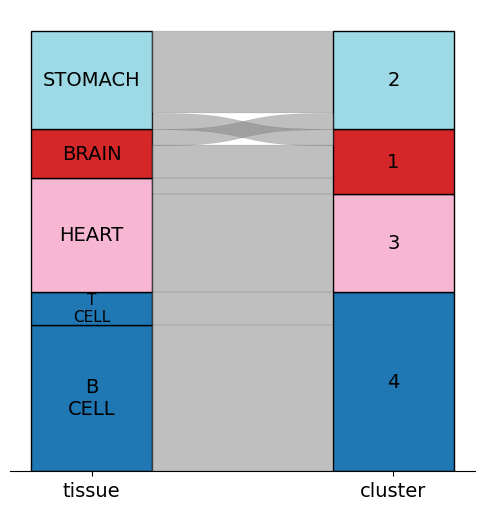

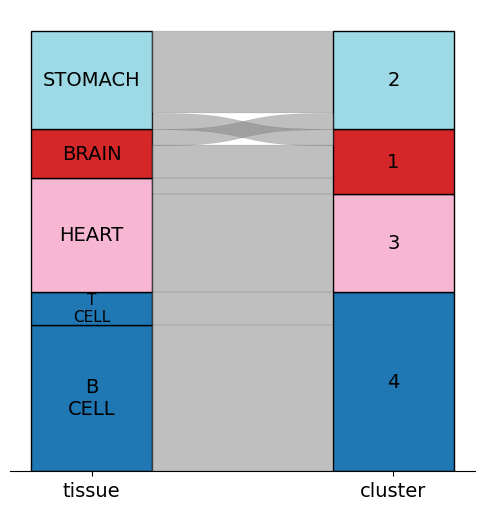

In [7]:
fig, ax = plot_alluvial(
    df=df,
    graphing_columns=graphing_columns,
    sorting_algorithm="tsp",
    match_colors=True,
    coloring_algorithm="advanced",
    coloring_algorithm_advanced_option="leiden",
    include_labels_in_boxes=True,
)
fig